<a href="https://colab.research.google.com/github/Panini783/machineLearn/blob/main/%D0%9B%D0%912_%D0%A1%D0%BB%D1%8E%D1%81%D0%B0%D1%80_%D0%A4%D0%86%D0%A23_10_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Слюсар, ФІТ 3-10

# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"

tables = pd.read_html(
    url,
    storage_options={"User-Agent": "Mozilla/5.0"}
)

print(len(tables))
df = tables[2]
df.head()

8


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [25]:
df.head(5)

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [26]:
df.shape  # (кількість_рядків, кількість_стовпців)

(222, 4)

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [29]:
# Подивитись назви всіх стовпців
df.columns

keep_cols = ['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]']
df = df[keep_cols]
df.head()

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [30]:
df = df.replace("—", np.nan)


In [32]:
for col in ['IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [33]:
df.isnull().sum()

,0
Country/Territory,0
IMF (2026)[1],31
World Bank (2025)[6],35
United Nations (2024)[7],9


5. Ще раз вивести датасет

In [34]:
df

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df = df.drop_duplicates()

In [37]:
df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [38]:
df.describe()

,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
count,1.910000e+02,1.870000e+02,2.130000e+02
mean,1.319229e+06,1.255590e+06,1.043818e+06
std,9.532709e+06,9.034696e+06,7.994824e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.560750e+04,1.561900e+04,8.549000e+03
50%,5.422800e+04,5.206100e+04,3.709400e+04
75%,3.689105e+05,3.259470e+05,2.571450e+05
max,1.262953e+08,1.183502e+08,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [39]:
# Створюємо новий стовпець з різницею
df['Diff_IMF_WB'] = df['IMF (2026)[1]'] - df['World Bank (2025)[6]']

# Подивитись кілька рядків
df[['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]', 'Diff_IMF_WB']].head()

# Країни, де різниця найбільша за модулем
df_diff_sorted = df.sort_values('Diff_IMF_WB', key=lambda s: s.abs(), ascending=False)
df_diff_sorted[['Country/Territory', 'Diff_IMF_WB']].head(10)

,Country/Territory,Diff_IMF_WB
0,World,7945165.0
1,United States,1614220.0
2,China[n 1],1353554.0
3,Germany,401935.0
10,Brazil,355992.0
12,Australia,325444.0
13,Mexico,288214.0
5,United Kingdom,262206.0
7,France,229778.0
6,India,197124.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [40]:
corr_matrix = df[['IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']].corr()
corr_matrix

,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
IMF (2026)[1],1.000000,0.999986,0.999966
World Bank (2025)[6],0.999986,1.000000,0.999982
United Nations (2024)[7],0.999966,0.999982,1.000000


Обчислити середнє значення за стовпцями

In [41]:
means = df[['IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']].mean()
means

,0
IMF (2026)[1],1.319229e+06
World Bank (2025)[6],1.255590e+06
United Nations (2024)[7],1.043818e+06


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [42]:
# Стандартне відхилення по трьох роках для кожної країни
df['Std_by_country'] = df[['IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']].std(axis=1)

# Країна з найбільшим Std
most_variable_row = df.loc[df['Std_by_country'].idxmax()]
most_variable_row

,0
Country/Territory,World
IMF (2026)[1],126295331.0
World Bank (2025)[6],118350166.0
United Nations (2024)[7],111565144.0
Diff_IMF_WB,7945165.0
Std_by_country,7372703.930408


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [43]:
# IMF 2026
max_imf = df.loc[df['IMF (2026)[1]'].idxmax()]
min_imf = df.loc[df['IMF (2026)[1]'].idxmin()]

# World Bank 2025
max_wb = df.loc[df['World Bank (2025)[6]'].idxmax()]
min_wb = df.loc[df['World Bank (2025)[6]'].idxmin()]

# UN 2024
max_un = df.loc[df['United Nations (2024)[7]'].idxmax()]
min_un = df.loc[df['United Nations (2024)[7]'].idxmin()]

max_imf, min_imf, max_wb, min_wb, max_un, min_un

(Country/Territory                    World
 IMF (2026)[1]                  126295331.0
 World Bank (2025)[6]           118350166.0
 United Nations (2024)[7]       111565144.0
 Diff_IMF_WB                      7945165.0
 Std_by_country              7372703.930408
 Name: 0, dtype: object,
 Country/Territory             Tuvalu
 IMF (2026)[1]                   65.0
 World Bank (2025)[6]            57.0
 United Nations (2024)[7]        56.0
 Diff_IMF_WB                      8.0
 Std_by_country              4.932883
 Name: 221, dtype: object,
 Country/Territory                    World
 IMF (2026)[1]                  126295331.0
 World Bank (2025)[6]           118350166.0
 United Nations (2024)[7]       111565144.0
 Diff_IMF_WB                      7945165.0
 Std_by_country              7372703.930408
 Name: 0, dtype: object,
 Country/Territory             Tuvalu
 IMF (2026)[1]                   65.0
 World Bank (2025)[6]            57.0
 United Nations (2024)[7]        56.0
 Diff_IMF_WB   

13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

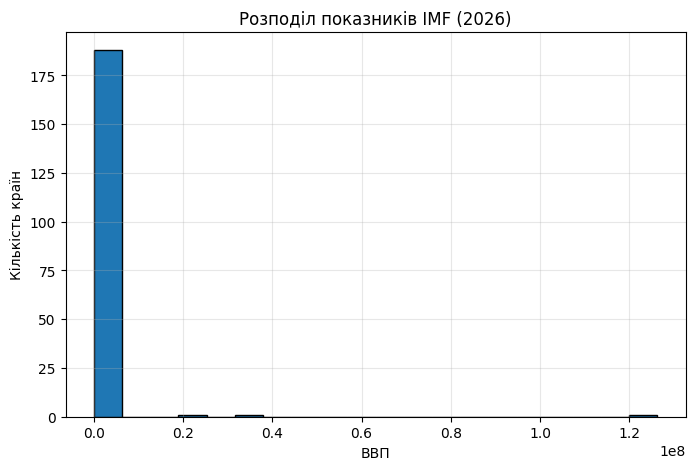

In [48]:
plt.figure(figsize=(8, 5))
plt.hist(df['IMF (2026)[1]'], bins=20, edgecolor='black')
plt.title('Розподіл показників IMF (2026)')
plt.xlabel('ВВП')
plt.ylabel('Кількість країн')
plt.grid(alpha=0.3)
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [46]:
# Загальне значення по кожному року
total_imf = df['IMF (2026)[1]'].sum()
total_wb = df['World Bank (2025)[6]'].sum()
total_un = df['United Nations (2024)[7]'].sum()

# Частка для кожної країни
df['Share_IMF'] = df['IMF (2026)[1]'] / total_imf
df['Share_WB'] = df['World Bank (2025)[6]'] / total_wb
df['Share_UN'] = df['United Nations (2024)[7]'] / total_un

df[['Country/Territory', 'Share_IMF', 'Share_WB', 'Share_UN']].head()


#в таблиці видно що зміни часток країн є не дуже значними

,Country/Territory,Share_IMF,Share_WB,Share_UN
0,World,0.501226,0.504057,0.501792
1,United States,0.128521,0.131049,0.131775
2,China[n 1],0.082753,0.083043,0.084305
3,Germany,0.021641,0.021512,0.020959
4,Japan,0.017380,0.018889,0.018109


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

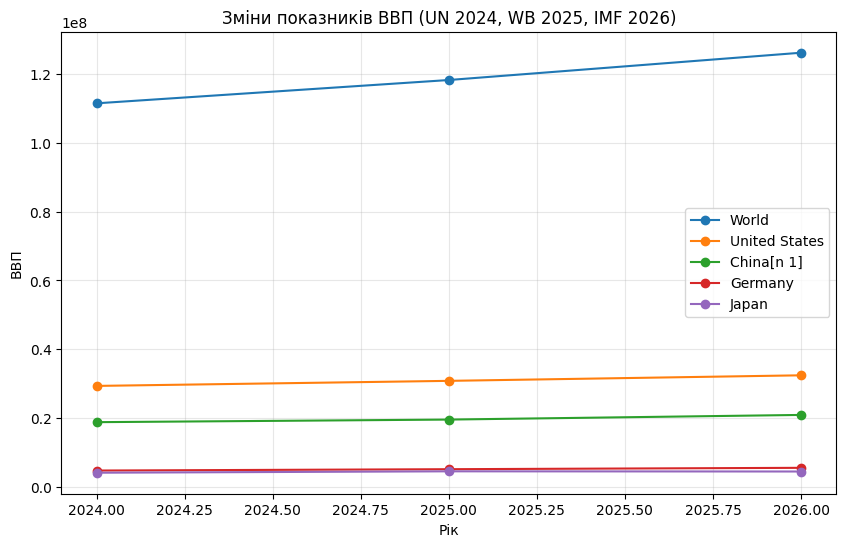

In [49]:
# Обрати топ-5 країн за середнім значенням
df['Mean_GDP'] = df[['IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']].mean(axis=1)
top5 = df.sort_values('Mean_GDP', ascending=False).head(5)

years = ['United Nations (2024)[7]', 'World Bank (2025)[6]', 'IMF (2026)[1]']

plt.figure(figsize=(10, 6))
for _, row in top5.iterrows():
    plt.plot(
        [2024, 2025, 2026],
        [row['United Nations (2024)[7]'], row['World Bank (2025)[6]'], row['IMF (2026)[1]']],
        marker='o',
        label=row['Country/Territory']
    )

plt.title('Зміни показників ВВП (UN 2024, WB 2025, IMF 2026)')
plt.xlabel('Рік')
plt.ylabel('ВВП')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

на графіку зверху ми можем побачити що китай та німеччина має більш замітний ріст ввп за 2 роки, в той час як японія та сша мают лише малі відхилення.
